In [1]:
import numpy as np
import os

from models.granger_pca import GrangerPCA
from models.teleconnection_models import RegressionAnalysis, CompositeAnalysis, CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from utils.granger_causality_test import test_granger_causality, test_granger_causality_non_parametric
from matplotlib import pyplot as plt
import seaborn as sns

import pandas as pd

## Generating data

In [2]:
# Ensure results directory exists
os.makedirs("results/synth/", exist_ok=True)

# Set random seed
np.random.seed(2025)

# Parameters
dw = 5
N = 100
d = 10

# Generate base signals
t = np.arange(1, N+1)
X = np.random.normal(0, 1, (N, 1)) + np.sin(0.2 * t)[:, None] + np.cos(0.1 * t)[:, None]
Z1 = np.random.normal(0, 1, (N, 1)) + np.cos(0.4 * t)[:, None]
Z2 = np.random.normal(0, 1, (N, 1)) + np.cos(0.05 * t)[:, None]

# X = np.random.exponential(1, (N, 1)) + np.sin(0.2 * t)[:, None] + np.cos(0.1 * t)[:, None]
# Z1 = np.random.exponential(1, (N, 1)) + np.cos(0.4 * t)[:, None]
# Z2 = np.random.exponential(1, (N, 1)) + np.cos(0.05 * t)[:, None]
# Initialize W
W = np.random.randn(N, dw)

# Generate W according to VAR-like dependencies
for i in range(3, N):  # start from index 3 because of lag terms
    W[i, 0] += (0.2 * W[i-2, 0] + 0.4 * X[i-1, 0] + 0.3 * X[i-2, 0] +
                0.2 * X[i-3, 0] + 0.2 * Z1[i-1, 0] + 0.2 * Z1[i-2, 0])

    # W[i, 0] += (0.2 * W[i-2, 0] + 0.04 * X[i-1, 0] + 0.03 * X[i-2, 0] +
    #             0.02 * X[i-3, 0] + 0.2 * Z1[i-1, 0] + 0.2 * Z1[i-2, 0])
    
    W[i, 1] += 0.4 * W[i-1, 1] + 0.5 * Z1[i-1, 0]
    
    W[i, 2] += 0.1 * W[i-2, 2] + 0.8 * Z1[i-2, 0] + 0.8 * W[i-1, 0] + 0.4 * W[i-2, 0]
    
    W[i, 3] += 0.1 * W[i-2, 3] - 0.7 * Z2[i-3, 0] + 0.8 * W[i-2, 2]
    
    W[i, 4] += 0.1 * W[i-1, 4] + 0.8 * Z1[i-2, 0] + 0.6 * Z2[i-1, 0] + 0.2 * Z2[i-2, 0]

# Generate high-dimensional X
AA = np.random.randn(dw, d)
Y = W #@ AA  # Matrix multiplication

# Save to CSV
np.savetxt("results/synth/X.csv", X, delimiter=",")
np.savetxt("results/synth/Y.csv", Y, delimiter=",")

## Data precprocessing
* Splitting data

In [3]:
n = len(Y)
train_size = int(n * 0.8)

Y_train = Y[:train_size, :]
Y_test  = Y[train_size:, :]

X_train = X[:train_size, :]
X_test  = X[train_size:, :]

W_0_train = W[:train_size, 0]
W_0_test = W[train_size:, 0]

100%|██████████| 7/7 [00:02<00:00,  3.41it/s]


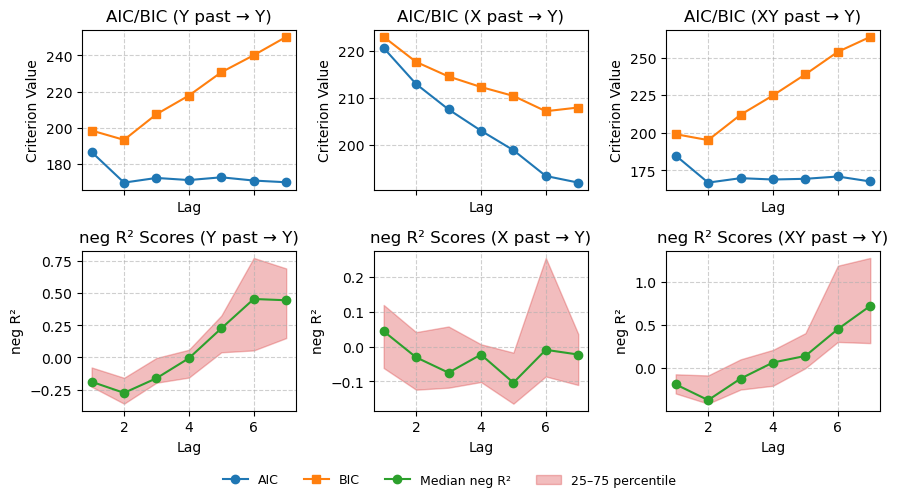

conflicted sign: lag 1:positive, lag 2:negative
       eigs
0  0.774490
1  0.091708


In [4]:
gpca = GrangerPCA(maxlag=None, maxlags=range(1, 8), method='diff_ratio', lag_criterion='BIC')
gpca.fit(X_train, Y_train, Z=None, plot_lag_analysis=True, verbose=True)

In [5]:
cp_test_gpca = gpca.transform(Y_test)
results_gpca = test_granger_causality_non_parametric(X_test, cp_test_gpca[:, 0], maxlag=gpca.maxlag)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:15<00:00, 15.06s/it]


In [6]:
ca = CompositeAnalysis(maxlag=gpca.maxlag)
ca.fit(X_train, Y_train)
cp_test_ca = ca.transform(Y_test, type='PosNeg')

ra = RegressionAnalysis(maxlag=gpca.maxlag)
ra.fit(X_train, Y_train)
cp_test_ra = ra.transform(Y_test)

cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1)
cca.fit(X_train, Y_train)
cp_test_cca = cca.transform(Y_test)

sa = SpatialAveraging()
sa.fit(X_train, Y_train)
cp_test_sa = sa.transform(Y_test)

pc = PrincipalComponents()
pc.fit(X_train, Y_train)
cp_test_pc = pc.transform(Y_test)

In [7]:
results_gpca = test_granger_causality(X_test[:, None], cp_test_gpca[:, 0], maxlag=[gpca.maxlag])
results_ra = test_granger_causality(X_test[:, None], cp_test_ra, maxlag=[gpca.maxlag])
results_ca = test_granger_causality(X_test[:, None], cp_test_ca, maxlag=[gpca.maxlag])
results_cca = test_granger_causality(X_test[:, None], cp_test_cca, maxlag=[gpca.maxlag])
results_sa = test_granger_causality(X_test[:, None], cp_test_sa, maxlag=[gpca.maxlag])
results_pc = test_granger_causality(X_test[:, None], cp_test_pc, maxlag=[gpca.maxlag])

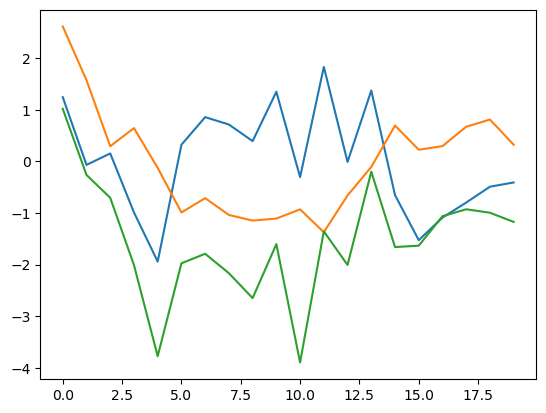

In [8]:
plt.plot(cp_test_gpca[-100:, 0])
plt.plot(cp_test_ca[-100:])
plt.plot(W_0_test[-100:])

In [9]:
# Combine your results (with method names as keys)
combined = pd.concat(
    [
        results_gpca[results_gpca['lag'] == gpca.maxlag],
        results_cca[results_cca['lag'] == gpca.maxlag],
        results_ca[results_ca['lag'] == gpca.maxlag],
        results_ra[results_ra['lag'] == gpca.maxlag],
        results_sa[results_sa['lag'] == gpca.maxlag],
        results_pc[results_pc['lag'] == gpca.maxlag]
    ],
    keys=['GPCA', 'CCA', 'Composites', 'Regression', 'Spatial Average', 'PCA']
).reset_index(level=0).rename(columns={'level_0': 'Method'})

# Export to LaTeX
latex_table = combined[['F_statistic', 'p_value']].to_latex(
    index=True,          # Don't include DataFrame index in table
    caption=f"Comparison of Results by Method at lag = {gpca.maxlag}",
    label="tab:results_by_method",
    float_format="%.6f",  # format numbers (3 decimals)
    escape=True          # allows LaTeX symbols like _ in column names
)

# Save to file
with open(f"tables/synthetic_pvalues.tex", "w") as f:
    f.write(latex_table)


In [10]:
combined

,Method,lag,Y_column,F_statistic,df1,df2,p_value,F_critical,alpha_used,interpretation
0,GPCA,2,1,3.119810,2,14,0.075767,3.738892,0.05,Fail to reject H₀: no Granger causality for Y ...
0,CCA,2,1,2.476924,2,14,0.119954,3.738892,0.05,Fail to reject H₀: no Granger causality for Y ...
0,Composites,2,1,2.412970,2,14,0.125776,3.738892,0.05,Fail to reject H₀: no Granger causality for Y ...
0,Regression,2,1,1.536307,2,14,0.249342,3.738892,0.05,Fail to reject H₀: no Granger causality for Y ...
0,Spatial Average,2,1,2.012975,2,14,0.170455,3.738892,0.05,Fail to reject H₀: no Granger causality for Y ...
0,PCA,2,1,1.986020,2,14,0.174066,3.738892,0.05,Fail to reject H₀: no Granger causality for Y ...


In [11]:
# Compute weights (same as your setup)
weights_gpca = np.abs(gpca.vects_)[:, 0, None] / np.abs(gpca.vects_)[:, 0, None].max()
weights_ra = np.abs(ra.lr.coef_) / np.abs(ra.lr.coef_.max())
weights_ca = np.abs(ca.composites['PosNeg'].to_numpy())[:, None] / np.abs(ca.composites['PosNeg'].to_numpy()[:, None].max())
weights_cca = np.abs(cca.cca.y_loadings_) / np.abs(cca.cca.y_loadings_.max())
weights_pc = np.abs(pc.pca.components_.T) / np.abs(pc.pca.components_[0, :].max())


    ax.set_title(method)
    ax.set_xlabel("N (log)")

axes[0].set_ylabel("m (log)")

cbar = fig.colorbar(sc, ax=axes, orientation="vertical")
cbar.set_label("p-value")

plt.tight_layout()
plt.savefig("figures/grid_experiments/grid_scatter_all_methods.png", dpi=300)
plt.show()

print("Finished all grid experiments.")
# Combine into DataFrame
df_weights = pd.DataFrame(
    np.array([weights_gpca, weights_ra, weights_ca, weights_cca, weights_pc])[:, :, 0].T,
    columns=['GPCA', 'RA', 'CA', 'CCA', 'PCA']
)

# --- Styling setup ---
sns.set_theme(context='paper', style='white', font='sans-serif', font_scale=1.2)
plt.figure(figsize=(6, 5))  # small, tight figure

# --- Heatmap ---
ax = sns.heatmap(
    df_weights,
    cmap='magma',
    cbar_kws={'shrink': 0.7, 'label': 'Normalized Weight'},
    linewidths=0.0,
    linecolor='white',
    square=False,        # <- allow rectangular cells
    fmt='.2f',
    annot_kws={"size": 9, "color": "black"},
    yticklabels=False
)

# --- Custom Y labels: 5 equally spaced blocks ---
labels = ["A", "B", "C", "D", "E"]
n_blocks = len(labels)
n_rows = df_weights.shape[0]

block_size = n_rows / n_blocks
tick_positions = [block_size*(i + 0.5) for i in range(n_blocks)]

ax.set_yticks(tick_positions)
ax.set_yticklabels(labels, rotation=0, fontsize=12)

# --- Labels & layout ---
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Component Block', fontsize=12)

# --- Polish ticks ---
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_aspect("auto")  # allow vertical squeezing

plt.tight_layout()

# --- Save ---
plt.savefig('figures/weights_toy_model.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


IndentationError: unexpected indent (2288085054.py, line 9)